## Pillar automatic characterization script

In [2]:
# position as array or dict
position = {'x': 0, 'y': 0, 'z': 0}
poi_manager_logic.move_scanner(position)

In [3]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
scan_data = scanning_data_logic.get_current_scan_data()

In [4]:
source = 'APD3'

data = scan_data.data[source]
(xrange,yrange) = scan_data.scan_range

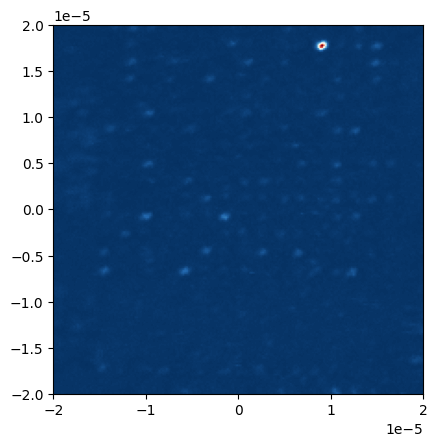

In [5]:
imgdata = np.fliplr(np.array(data)).transpose() # scudi displayes in a weird way.
extent=[xrange[0],xrange[1],yrange[0],yrange[1]]
plt.imshow(imgdata, extent=extent, cmap='RdBu_r')

In [7]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

In [12]:
import time

In [ ]:
def do_optimize():
    a = scanning_optimize_logic.start_optimize()
    while scanning_optimize_logic.module_state()=='locked':
        time.sleep(1)
    return

In [4]:
def move_in_xy(x,y):
    scanning_probe_logic.set_target_position({'x':x, 'y':y})
    # time.sleep(0.1)

    return
def move_by_step(x_step, y_step):
    current_x, current_y = scanning_probe_logic.scanner_target['x'], scanning_probe_logic.scanner_target['y']
    new_x = current_x + x_step
    new_y = current_y + y_step
    move_in_xy(new_x, new_y)
    return

    # Example usage
    
x0, y0 = scanning_probe_logic.scanner_target['x'], scanning_probe_logic.scanner_target['y']
# move_in_xy(x0, y0)

In [35]:
move_by_step(-1e-06, -1e-06)

In [5]:
poi_manager_logic.poi_names

['tin1', 'tin2', 'tin3', 'tin4', 'tin5', 'tin6', 'tin7', 'tin8', 'tin9', 'tin10', 'tin11', 'tin12', 'tin13', 'tin14', 'tin15', 'tin16', 'tin17', 'tin18', 'tin19', 'tin20', 'tin21', 'tin22', 'tin23', 'tin24', 'tin25', 'tin26', 'tin27', 'tin28', 'tin29', 'tin30', 'tin31', 'tin32', 'tin33', 'tin34', 'tin35', 'tin36', 'tin37', 'tin38', 'tin39', 'tin40', 'tin41', 'tin42', 'tin43', 'tin44', 'tin45', 'tin46', 'tin47', 'tin48', 'tin49', 'tin50', 'tin51', 'tin52', 'tin53', 'tin54', 'tin55', 'tin56', 'tin57', 'tin58', 'tin59', 'tin60', 'tin61', 'tin62', 'tin63', 'tin64', 'tin65', 'tin66', 'tin67', 'tin68', 'tin69', 'tin70', 'tin71', 'tin72', 'tin73', 'tin74', 'tin75', 'tin76', 'tin77', 'tin78', 'tin79', 'tin80', 'tin81', 'tin82', 'tin83', 'tin84', 'tin85', 'tin86', 'tin87', 'tin88', 'tin89', 'tin90', 'tin91', 'tin92', 'tin93', 'tin94', 'tin95', 'tin96', 'tin97', 'tin98', 'tin99', 'tin100', 'tin101', 'tin102', 'tin103', 'tin104', 'tin105', 'tin106', 'tin107', 'tin108', 'tin109']

In [6]:
def move_to_poi(poi_name):
    """Move the scanner to a specific POI."""
    target_x, target_y = poi_manager_logic.get_poi_position(poi_name)
    move_in_xy(target_x, target_y)
    time.sleep(0.2)  # Allow stabilization

In [7]:
scanning_probe_logic.scanner_target['x'], scanning_probe_logic.scanner_target['y']

(6.5519e-06, 6.7667e-06)

In [8]:
poi_manager_logic.get_poi_position(first_poi)

NameError: name 'first_poi' is not defined

In [9]:
def identify_hysteresis_offset(poi_name):
    """
    Identify the hysteresis offset by moving to the target position,
    measuring the actual position, and calculating the error.
    """
    # move_to_poi(poi_name)
    # time.sleep(0.5)  # Let the scanner settle
    actual_x, actual_y = scanning_probe_logic.scanner_target['x'], scanning_probe_logic.scanner_target['y']
    target_x, target_y, z = poi_manager_logic.get_poi_position(poi_name)
    
    offset_x = target_x - actual_x
    offset_y = target_y - actual_y
    return offset_x, offset_y

def apply_hysteresis_correction(target_x, target_y, offset_x, offset_y):
    """Compensate for hysteresis when moving to a new POI."""
    corrected_x = target_x - offset_x
    corrected_y = target_y - offset_y
    move_in_xy(corrected_x, corrected_y)
    time.sleep(0.2)  # Allow stabilization

In [17]:
pois = poi_manager_logic.poi_names
save_folder = r'Z:\Vlad\heavyIV\202-2-ARed\Corner-B3\spectrum2'

In [11]:
first_poi = pois[0]

In [12]:
hysteresis_offset_x, hysteresis_offset_y = identify_hysteresis_offset(first_poi)

In [14]:
import time

In [15]:
target_x, target_y, z = poi_manager_logic.get_poi_position(first_poi)
apply_hysteresis_correction(target_x, target_y, hysteresis_offset_x, hysteresis_offset_y)
time.sleep(0.25)

In [18]:
pois = poi_manager_logic.poi_names
for poi in pois:
    print(f"Measuring {poi}")
    target_x, target_y, z = poi_manager_logic.get_poi_position(poi)
    apply_hysteresis_correction(target_x, target_y, hysteresis_offset_x, hysteresis_offset_y)
    time.sleep(0.25)
    for i in range(2):
        scanning_optimize_logic.start_optimize()
        while scanning_optimize_logic.module_state() == 'locked':
            time.sleep(1)

    spectrometerlogic_pi.run_get_spectrum()
    while spectrometerlogic_pi._acquisition_running:
        time.sleep(1)
    
    spectrometerlogic_pi.save_spectrum_data(False, f"{poi}", save_folder)
    

Measuring tin1
Measuring tin2
Measuring tin3
Measuring tin4
Measuring tin5
Measuring tin6
Measuring tin7
Measuring tin8
Measuring tin9
Measuring tin10
Measuring tin11
Measuring tin12
Measuring tin13
Measuring tin14
Measuring tin15
Measuring tin16
Measuring tin17
Measuring tin18
Measuring tin19
Measuring tin20
Measuring tin21
Measuring tin22
Measuring tin23
Measuring tin24
Measuring tin25
Measuring tin26
Measuring tin27
Measuring tin28
Measuring tin29
Measuring tin30
Measuring tin31
Measuring tin32
Measuring tin33
Measuring tin34
Measuring tin35
Measuring tin36
Measuring tin37
Measuring tin38
Measuring tin39
Measuring tin40
Measuring tin41
Measuring tin42
Measuring tin43
Measuring tin44
Measuring tin45
Measuring tin46
Measuring tin47
Measuring tin48
Measuring tin49
Measuring tin50
Measuring tin51
Measuring tin52
Measuring tin53
Measuring tin54
Measuring tin55
Measuring tin56
Measuring tin57
Measuring tin58
Measuring tin59
Measuring tin60
Measuring tin61
